In [1]:
# Cell 1: Environment Handshaking
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from src.data_processing import load_and_cache_entire_fleet, downsample_block_mean, fit_dtmc
from src.simulator import Simulator
from src.controllers import ThresholdControl, StochasticControl

@dataclass(frozen=True)
class SimConfig:
    k_s: float = 1.0           # Switching cost coefficient
    p_star: float = 200.0      # Reference power capacity per module [kW]
    n0: int = 5                # Initial active fuel cell modules
    Ts: int = 300              # Macro sample rate [s]
    n_states: int = 16         # Number of discrete load levels (M=16 in data execution block)
    alpha: float = 0.5         # Dirichlet smoothing parameter
    n_vals: np.ndarray = field(default_factory=lambda: np.arange(1, 11, dtype=np.int32)) #
    sigma: float = 0.5

config = SimConfig()
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print("Modular package extensions ready.")

Modular package extensions ready.


In [2]:
# Cell 2: Triggering the Single-Pass In-Memory Cache
# This runs the disk I/O once, keeping your system fast for all later validations
FLEET_CACHE = load_and_cache_entire_fleet(config)

Beginning memory staging of all 14 fleet files into RAM...
 -> Day 01 successfully cached in RAM.
 -> Day 02 successfully cached in RAM.
 -> Day 03 successfully cached in RAM.
 -> Day 04 successfully cached in RAM.
 -> Day 05 successfully cached in RAM.
 -> Day 06 successfully cached in RAM.
 -> Day 07 successfully cached in RAM.
 -> Day 08 successfully cached in RAM.
 -> Day 09 successfully cached in RAM.
 -> Day 10 successfully cached in RAM.
 -> Day 11 successfully cached in RAM.
 -> Day 12 successfully cached in RAM.
 -> Day 13 successfully cached in RAM.
 -> Day 14 successfully cached in RAM.

All 14 operational days securely held in RAM. Disk I/O locked.


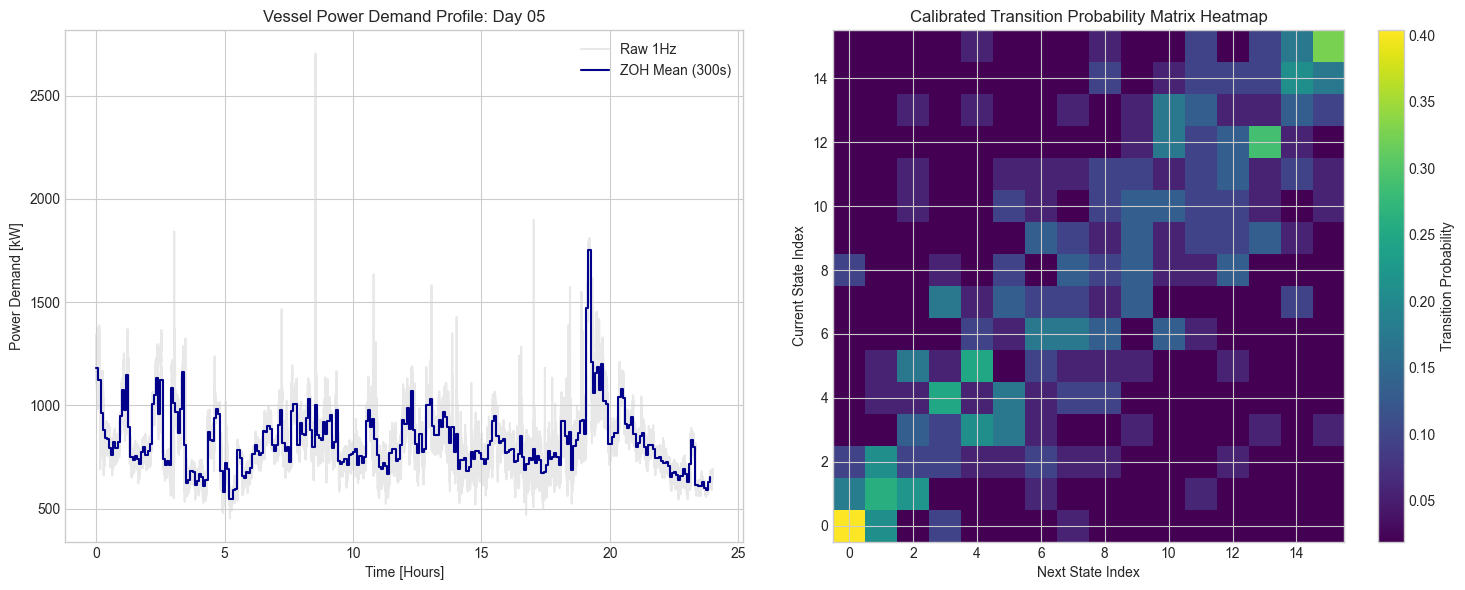

In [3]:
# Cell 3: Missing Figures Recovery (ZOH Profiles & Transition Heatmaps)
# Visualize a clean sample day (Day 8) to match the report's layout
sample_day = 5
raw_day = FLEET_CACHE[sample_day]
ds_day = downsample_block_mean(raw_day['t'], raw_day['Pd'], config.Ts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Zero-Order Hold (ZOH) representation
ax1.plot(raw_day['t'] / 3600, raw_day['Pd'], color='lightgray', alpha=0.5, label='Raw 1Hz')
ax1.step(ds_day['left_edges'] / 3600, ds_day['Pd'], where='post', color='darkblue', label=f'ZOH Mean ({config.Ts}s)')
ax1.set_title(f"Vessel Power Demand Profile: Day {sample_day:02d}")
ax1.set_xlabel("Time [Hours]")
ax1.set_ylabel("Power Demand [kW]")
ax1.legend()

# Subplot 2: Heatmap of a standard single-day transition model
mc_sample = fit_dtmc(ds_day['Pd'], config.n_states, config.alpha)
im = ax2.imshow(mc_sample['P'], cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax2, label='Transition Probability')
ax2.set_title("Calibrated Transition Probability Matrix Heatmap")
ax2.set_xlabel("Next State Index")
ax2.set_ylabel("Current State Index")

plt.tight_layout()
plt.show()

In [4]:
# Cell 4: Pre-Validation Model Diagnostics & Discretization Sanity Check (Active Sea-Trial Baseline)

# 1. Run a quick full-fleet downsampling sweep across active cached RAM segments (Days 4-14)
all_fleet_pd = []
active_keys = [d for d in sorted(list(FLEET_CACHE.keys())) if d >= 4]

for d in active_keys:
    ds_seg = downsample_block_mean(FLEET_CACHE[d]['t'], FLEET_CACHE[d]['Pd'], config.Ts)
    all_fleet_pd.append(ds_seg['Pd'])

# Generate the global baseline model across active operational days only
global_mc = fit_dtmc(all_fleet_pd, config.n_states, config.alpha)

# 2. Extract and compile physical metrics exclusively for active days
raw_concatenated = np.concatenate([FLEET_CACHE[d]['Pd'] for d in active_keys])
ds_concatenated = np.concatenate(all_fleet_pd)

state_levels = global_mc['levels']
edges = global_mc['edges']
stationary_probs = global_mc['pi']
state_gaps = np.diff(state_levels)

# 3. Print a structural plain-text summary of your physical dataset
print("=" * 80)
print("                    MARINER FLEET OPERATIONAL BASELINE METRICS (DAYS 4-14)")
print("=" * 80)
print(f" -> High-Frequency 1Hz Data Size   : {len(raw_concatenated):,} active raw load readings")
print(f" -> Aggregated Macro-Interval Blocks: {len(ds_concatenated):,} intervals (Ts = {config.Ts}s)")
print(f" -> Active Peak Load Observed       : {np.max(raw_concatenated):.2f} kW")
print(f" -> Active Base Load Observed       : {np.min(raw_concatenated):.2f} kW")
print(f" -> Active Fleet Mean Power Demand   : {np.mean(raw_concatenated):.2f} kW")
print(f" -> Configured Tracking State Resolution : {config.n_states} Quantile Intervals")
print(f" -> Average Operational Discretization Gap : {np.mean(state_gaps):.2f} kW")
print("=" * 80)

# 4. Compile and print a copy-pasteable Markdown table mapping out each individual discrete state mode
state_records = []
for idx in range(config.n_states):
    state_records.append({
        "State Index": f"State {idx + 1:02d}",
        "Lower Bin Edge [kW]": edges[idx],
        "Representative Level [kW]": state_levels[idx],
        "Upper Bin Edge [kW]": edges[idx + 1],
        "Stationary Probability (pi)": stationary_probs[idx]
    })

df_diagnostics = pd.DataFrame(state_records)

print("\n### DISCRETE MARKOV MODEL STATE CHARACTERISTICS (GLOBAL PROFILE)")
print(df_diagnostics.to_markdown(index=False, floatfmt=".4f"))
print("\n" + "=" * 80)

                    MARINER FLEET OPERATIONAL BASELINE METRICS (DAYS 4-14)
 -> High-Frequency 1Hz Data Size   : 950,399 active raw load readings
 -> Aggregated Macro-Interval Blocks: 3,168 intervals (Ts = 300s)
 -> Active Peak Load Observed       : 2798.91 kW
 -> Active Base Load Observed       : 350.23 kW
 -> Active Fleet Mean Power Demand   : 836.56 kW
 -> Configured Tracking State Resolution : 16 Quantile Intervals
 -> Average Operational Discretization Gap : 87.74 kW

### DISCRETE MARKOV MODEL STATE CHARACTERISTICS (GLOBAL PROFILE)
| State Index   |   Lower Bin Edge [kW] |   Representative Level [kW] |   Upper Bin Edge [kW] |   Stationary Probability (pi) |
|:--------------|----------------------:|----------------------------:|----------------------:|------------------------------:|
| State 01      |              451.7684 |                    493.5739 |              535.3795 |                        0.0629 |
| State 02      |              535.3795 |                    548.7043 |   

In [5]:
# Cell 5: Approach A - Leave-One-Day-Out (LOGO) Cross-Validation Framework
logo_results = []
# Explicitly filter out port-idling days 1, 2, and 3
active_days = [d for d in sorted(list(FLEET_CACHE.keys())) if d >= 4]

print("========================================================================")
print("EXECUTING LEAVE-ONE-DAY-OUT CROSS VALIDATION (14 SEQUENTIAL FOLDS)")
print("========================================================================")

for test_day in active_days:
    # Gather training segments from RAM, skipping the current test day
    train_days = [d for d in active_days if d != test_day]
    
    # Process and downsample each continuous block separately to avoid boundary gaps
    train_segments = []
    for d in train_days:
        raw_seg = FLEET_CACHE[d]
        ds_seg = downsample_block_mean(raw_seg['t'], raw_seg['Pd'], config.Ts)
        train_segments.append(ds_seg['Pd'])
        
    # Calibrate our segment-aware Markov model
    mc_model = fit_dtmc(train_segments, config.n_states, config.alpha)
    
    # Isolate out-of-sample testing track
    raw_test = FLEET_CACHE[test_day]
    ds_test = downsample_block_mean(raw_test['t'], raw_test['Pd'], config.Ts)
    test_Pd = ds_test['Pd']
    
    # Drive evaluation loops
    sim_stoch = Simulator(config, test_Pd)
    sim_thres = Simulator(config, test_Pd)
    
    ctrl_stoch = StochasticControl(
        k_s=config.k_s,
        p_star=config.p_star,
        states=mc_model['levels'],
        transition_matrix=mc_model['P'],
        n_vals=config.n_vals
    )
    
    cost_stoch = sim_stoch.run(ctrl_stoch)
    cost_thres = sim_thres.run(ThresholdControl(config))
    
    logo_results.append({
        'test_day': test_day,
        'Stochastic': cost_stoch,
        'Threshold': cost_thres
    })

df_logo = pd.DataFrame(logo_results)
print("\n" + "="*72)
print("FINAL CROSS-VALIDATION PORTFOLIO SUMMARY (FLEET-WIDE AVERAGES)")
print("="*72)
print(df_logo.mean(numeric_only=True).to_string())
print("="*72)

EXECUTING LEAVE-ONE-DAY-OUT CROSS VALIDATION (14 SEQUENTIAL FOLDS)

FINAL CROSS-VALIDATION PORTFOLIO SUMMARY (FLEET-WIDE AVERAGES)
test_day        9.000000
Stochastic    110.963297
Threshold      97.859757


In [6]:
# Cell 6: Approach B - Chronological Forward Chaining (Expanding Training Horizon)
fc_results = []

print("========================================================================")
print("EXECUTING TEMPORAL FORWARD CHAINING EXPANSION VALIDATION")
print("========================================================================")

# Loop chronologically from Day 4 up to Day 14
for split_idx in range(7, 15):
    test_day = split_idx
    # Training timeline grows day by day, preserving sequential boundaries
    train_days = list(range(4, split_idx))
    
    train_segments = []
    for d in train_days:
        raw_seg = FLEET_CACHE[d]
        ds_seg = downsample_block_mean(raw_seg['t'], raw_seg['Pd'], config.Ts)
        train_segments.append(ds_seg['Pd'])
        
    # Train expectation matrix on historical context accumulated so far
    mc_model = fit_dtmc(train_segments, config.n_states, config.alpha)
    
    # Evaluate performance on the chronologically next unseen day
    raw_test = FLEET_CACHE[test_day]
    ds_test = downsample_block_mean(raw_test['t'], raw_test['Pd'], config.Ts)
    test_Pd = ds_test['Pd']
    
    # Drive evaluation loops
    sim_stoch = Simulator(config, test_Pd)
    sim_thres = Simulator(config, test_Pd)
    
    ctrl_stoch = StochasticControl(
        k_s=config.k_s,
        p_star=config.p_star,
        states=mc_model['levels'],
        transition_matrix=mc_model['P'],
        n_vals=config.n_vals
    )
    
    cost_stoch = sim_stoch.run(ctrl_stoch)
    cost_thres = sim_thres.run(ThresholdControl(config))
    
    fc_results.append({
        'history_size_days': len(train_days),
        'Stochastic': cost_stoch,
        'Threshold': cost_thres
    })

df_fc = pd.DataFrame(fc_results)
print("Forward chaining sweeps completed.")

EXECUTING TEMPORAL FORWARD CHAINING EXPANSION VALIDATION
Forward chaining sweeps completed.


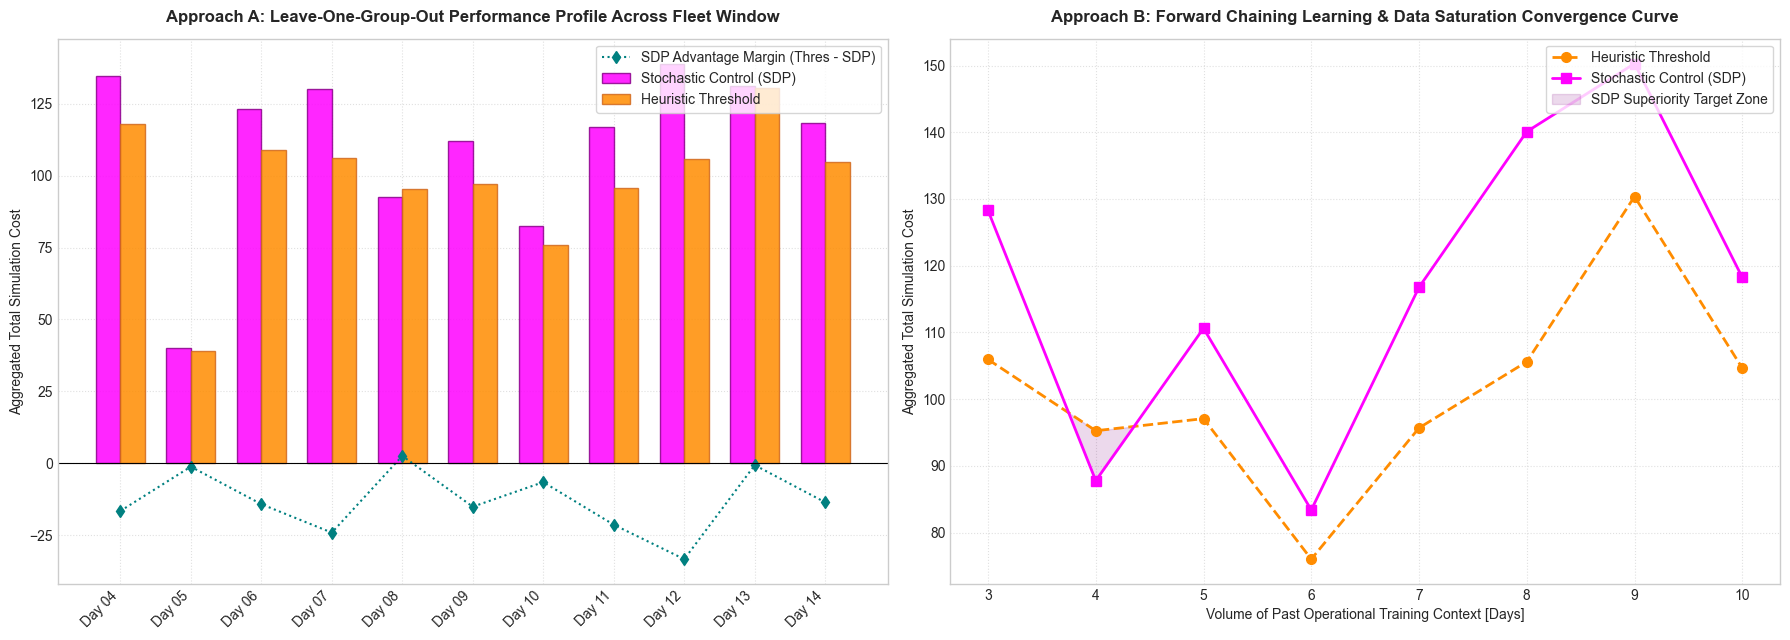

### APPROACH A: LEAVE-ONE-DAY-OUT CROSS-VALIDATION RESULTS
| Test Target   |   SDP Cost |   Heuristic Cost |   Delta Advantage (Thres - SDP) |
|:--------------|-----------:|-----------------:|--------------------------------:|
| Day 04        |     134.62 |           118.02 |                          -16.60 |
| Day 05        |      40.13 |            38.94 |                           -1.18 |
| Day 06        |     123.05 |           108.84 |                          -14.21 |
| Day 07        |     130.07 |           105.95 |                          -24.11 |
| Day 08        |      92.72 |            95.27 |                            2.55 |
| Day 09        |     112.19 |            97.08 |                          -15.10 |
| Day 10        |      82.58 |            76.02 |                           -6.56 |
| Day 11        |     117.05 |            95.69 |                          -21.36 |
| Day 12        |     138.95 |           105.61 |                          -33.34 |
| Day 13        |

In [7]:
# Cell 7: Advanced Validation Visualization Dashboard & Plain-Text Markdown Tables
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. GRAPHICAL DASHBOARD GENERATION
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6.5))

# --- Plot Panel 1: Approach A (Leave-One-Day-Out Cross-Validation Profile) ---
indices = np.arange(len(df_logo))
bar_width = 0.35

# Render paired bar configurations
rects1 = ax1.bar(indices - bar_width/2, df_logo['Stochastic'], bar_width, 
                 color='fuchsia', alpha=0.85, edgecolor='darkmagenta', linewidth=1, label='Stochastic Control (SDP)')
rects2 = ax1.bar(indices + bar_width/2, df_logo['Threshold'], bar_width, 
                 color='darkorange', alpha=0.85, edgecolor='chocolate', linewidth=1, label='Heuristic Threshold')

# Compute and plot an overlay line tracking localized out-of-sample margin superiority
delta_logo = df_logo['Threshold'] - df_logo['Stochastic']
ax1.plot(indices, delta_logo, color='teal', marker='d', linestyle=':', 
         linewidth=1.5, label='SDP Advantage Margin (Thres - SDP)')

ax1.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax1.set_xticks(indices)
ax1.set_xticklabels([f"Day {int(d):02d}" for d in df_logo['test_day']], rotation=45, ha='right')
ax1.set_title('Approach A: Leave-One-Group-Out Performance Profile Across Fleet Window', fontsize=12, fontweight='bold', pad=12)
ax1.set_ylabel('Aggregated Total Simulation Cost')
ax1.legend(loc='upper right', frameon=True, facecolor='white')
ax1.set_axisbelow(True)
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Plot Panel 2: Approach B (Forward Chaining Temporal Saturation Curve) ---
x_axis = df_fc['history_size_days']
ax2.plot(x_axis, df_fc['Threshold'], marker='o', linestyle='--', 
         color='darkorange', linewidth=2, markersize=7, label='Heuristic Threshold')
ax2.plot(x_axis, df_fc['Stochastic'], marker='s', linestyle='-', 
         color='fuchsia', linewidth=2, markersize=7, label='Stochastic Control (SDP)')

# Highlight regions to visually demarcate expectation matrix saturation limits
ax2.fill_between(x_axis, df_fc['Threshold'], df_fc['Stochastic'], 
                 where=(df_fc['Stochastic'] <= df_fc['Threshold']),
                 interpolate=True, color='purple', alpha=0.15, label='SDP Superiority Target Zone')

ax2.set_xticks(x_axis)
ax2.set_title('Approach B: Forward Chaining Learning & Data Saturation Convergence Curve', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Volume of Past Operational Training Context [Days]')
ax2.set_ylabel('Aggregated Total Simulation Cost')
ax2.legend(loc='upper right', frameon=True, facecolor='white')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. PLAIN-TEXT MARKDOWN TABLE PRINTER (FOR DIRECT COPY-PASTING TO .md FILES)
# ==============================================================================

# Prepare and augment dataframes with delta evaluations for strict reporting
df_logo_report = df_logo.copy()
df_logo_report['Test Target'] = df_logo_report['test_day'].apply(lambda d: f"Day {int(d):02d}")
df_logo_report['SDP Cost'] = df_logo_report['Stochastic']
df_logo_report['Heuristic Cost'] = df_logo_report['Threshold']
df_logo_report['Delta Advantage (Thres - SDP)'] = df_logo_report['Heuristic Cost'] - df_logo_report['SDP Cost']
cols_logo = ['Test Target', 'SDP Cost', 'Heuristic Cost', 'Delta Advantage (Thres - SDP)']

df_fc_report = df_fc.copy()
df_fc_report['Training Horizon History'] = df_fc_report['history_size_days'].apply(lambda h: f"{int(h)} Day(s)")
df_fc_report['Unseen Test Target'] = df_fc_report['history_size_days'].apply(lambda h: f"Day {int(h) + 1:02d}")
df_fc_report['SDP Cost'] = df_fc_report['Stochastic']
df_fc_report['Heuristic Cost'] = df_fc_report['Threshold']
df_fc_report['Delta Advantage (Thres - SDP)'] = df_fc_report['Heuristic Cost'] - df_fc_report['SDP Cost']
cols_fc = ['Training Horizon History', 'Unseen Test Target', 'SDP Cost', 'Heuristic Cost', 'Delta Advantage (Thres - SDP)']

# Print raw markdown strings directly to the output cell standard print stream
print("### APPROACH A: LEAVE-ONE-DAY-OUT CROSS-VALIDATION RESULTS")
print(df_logo_report[cols_logo].to_markdown(index=False, floatfmt=".2f"))

print("\n" + "="*80 + "\n")

print("### APPROACH B: CHRONOLOGICAL FORWARD CHAINING RESULTS")
print(df_fc_report[cols_fc].to_markdown(index=False, floatfmt=".2f"))

print("\n" + "="*80 + "\n")

print("### SUMMARY STATS")
print(f"* Fleet-Wide SDP Average Simulation Cost: {df_logo['Stochastic'].mean():.2f}")
print(f"* Fleet-Wide Heuristic Average Simulation Cost: {df_logo['Threshold'].mean():.2f}")
print(f"* Global Structural Generalization Advantage (Mean): {(df_logo['Threshold'].mean() - df_logo['Stochastic'].mean()):.2f}")